In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df= pd.read_csv("/content/netflix_titles.csv.zip")

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.duplicated().value_counts()

,count
False,8807


In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.drop(columns=['director'], inplace=True)

In [ ]:
df['cast'].fillna('unavailable', inplace=True)

In [ ]:
df['country'].fillna('unknown', inplace=True)

In [ ]:
df['date_added'].fillna(df['date_added'].mode()[0],inplace=True)

In [ ]:
df['rating'].fillna(df['rating'].mode()[0],inplace=True)

In [ ]:
df['duration'].fillna(df['duration'].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [ ]:
df = df[['type','title','listed_in','description']].dropna()

In [ ]:
df['features'] = df['listed_in'] + ' ' + df['description']

In [ ]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['features'])

In [ ]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())
df['x'] = X_pca[:, 0]
df['y'] = X_pca[:, 1]

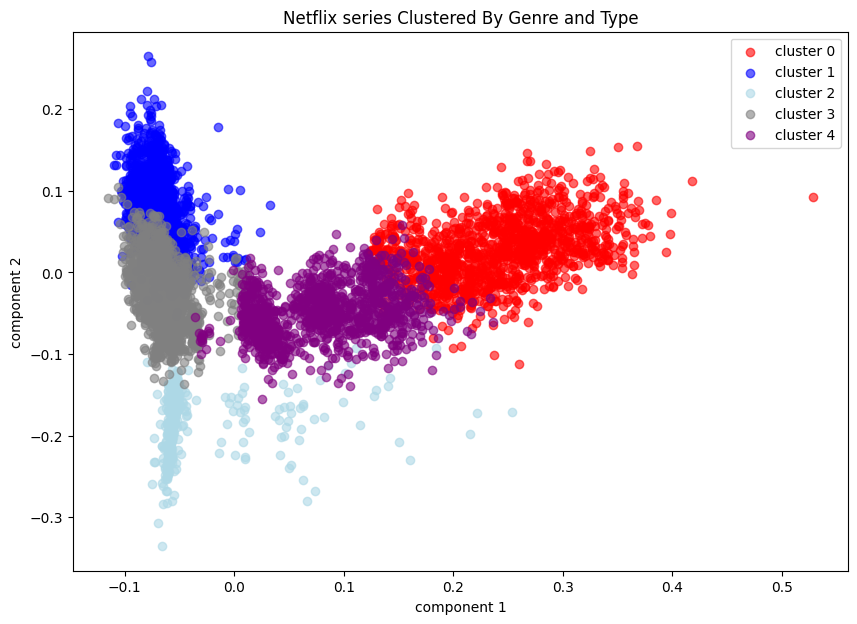

In [ ]:
plt.figure(figsize=(10,7))
colors= ['red', 'blue', 'lightblue', 'grey','purple']

for i in range (k):
  clustered = df[df['cluster'] == i]
  plt.scatter(clustered['x'],clustered['y'], label=f"cluster {i}",  alpha=0.6, color=colors[i % len(colors)])


plt.legend()
plt.title("Netflix series Clustered By Genre and Type")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.show()

In [ ]:
for i in range(k):
    print(f"Cluster {i} Sample Titles:")
    print(df[df['cluster'] == i][['title', 'listed_in', 'type']].sample(5, random_state=42))

Cluster 0 Sample Titles:
                        title  \
519             I AM A KILLER   
6263            Beating Again   
289         The Crowned Clown   
3940                Quicksand   
3375  Monzón: A Knockout Blow   

                                              listed_in     type  
519        British TV Shows, Crime TV Shows, Docuseries  TV Show  
6263  International TV Shows, Korean TV Shows, Roman...  TV Show  
289   International TV Shows, Romantic TV Shows, TV ...  TV Show  
3940  Crime TV Shows, International TV Shows, TV Dramas  TV Show  
3375  Crime TV Shows, International TV Shows, Spanis...  TV Show  
Cluster 1 Sample Titles:
                              title  \
8618                     Trash Fire   
6399  Cahaya Dari Timur Beta Maluku   
8226                   The Break-Up   
5101                 Fun Mom Dinner   
8126                       Superbad   

                                        listed_in   type  
8618         Comedies, Dramas, Independent Movies  Movi